# 01 - Exploratory Data Analysis

Interactive EDA companion to `code/data_acquisition_understanding/eda.py`. Calls the same functions so notebook and pipeline cannot drift.

**Sections**
1. Setup & load
2. Schema, missingness, class balance
3. Univariate distributions
4. Multivariate relationships (correlation, target overlays)
5. Persist plots & report tables

In [17]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / 'code'))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_theme(style='whitegrid')

from utils.paths import RAW_CSV, TARGET_COL, REPORTS, FIG_UNI, FIG_MULTI
from utils.logger import get_logger
logger = get_logger('eda_notebook')

## 1. Load raw data

In [18]:
df = pd.read_csv(RAW_CSV)
print('shape:', df.shape)
df.head()

shape: (10000, 10)


,transaction_id,user_id,amount,transaction_type,merchant_category,country,hour,device_risk_score,ip_risk_score,is_fraud
0,8132,1237,262.65,POS,Food,UK,21,0.565932,0.093534,0
1,8268,643,45.37,ATM,Grocery,DE,6,0.413392,0.093027,0
2,719,623,768.19,POS,Electronics,US,5,0.324167,0.308271,1
3,8237,1168,143.63,POS,Clothing,US,12,0.204927,0.115483,0
4,4555,346,1.00,ATM,Grocery,NG,19,0.286731,0.005794,0


## 2. Schema, missingness, class balance

In [19]:
summary = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing': df.isna().sum(),
    'missing_pct': df.isna().mean().mul(100).round(3),
    'n_unique': df.nunique(),
})
summary

,dtype,missing,missing_pct,n_unique
transaction_id,int64,0,0.0,10000
user_id,int64,0,0.0,1983
amount,float64,0,0.0,8029
transaction_type,object,0,0.0,4
merchant_category,object,0,0.0,5
country,object,0,0.0,6
hour,int64,0,0.0,24
device_risk_score,float64,0,0.0,9886
ip_risk_score,float64,0,0.0,9873
is_fraud,int64,0,0.0,2


In [20]:
balance = df[TARGET_COL].value_counts(dropna=False).rename('count').to_frame()
balance['pct'] = (balance['count'] / balance['count'].sum() * 100).round(3)
balance

,count,pct
is_fraud,,
0,9500,95.0
1,500,5.0


Strong class imbalance — this motivates SMOTE in preprocessing and using **F1 / precision / recall** (not accuracy) as success metrics.

## 3. Univariate plots

Delegate to the EDA module so notebook outputs match the persisted pipeline outputs.

In [21]:
from data_acquisition_understanding import eda
eda.summarise(df)
eda.univariate(df)
print('Saved univariate figures to:', FIG_UNI)

2026-05-26 15:52:04 | INFO     | eda | Wrote dataset summary -> C:\Users\U1\Documents\fraud-1\outputs\reports\data_summary.csv
2026-05-26 15:52:04 | INFO     | eda | Class balance:
          count   pct
is_fraud             
0          9500  95.0
1           500   5.0
2026-05-26 15:52:04 | INFO     | eda | Univariate plots: 4 numeric, 3 categorical features


2026-05-26 15:52:05 | INFO     | eda | Saved per-category fraud rates
Saved univariate figures to: C:\Users\U1\Documents\fraud-1\outputs\figures\univariate


c:\Users\U1\Documents\fraud-1\code\data_acquisition_understanding\eda.py:124: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=TARGET_COL, data=df, ax=ax, palette=["#4c72b0", "#c44e52"])


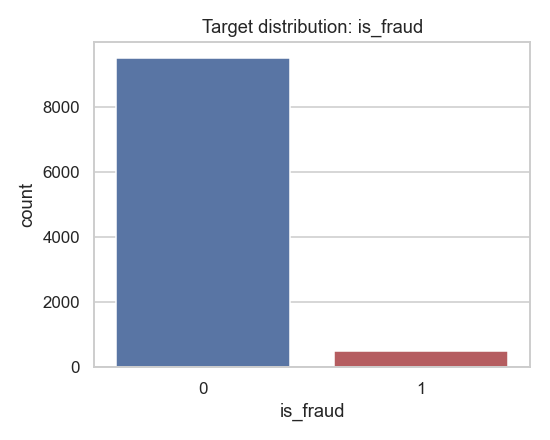

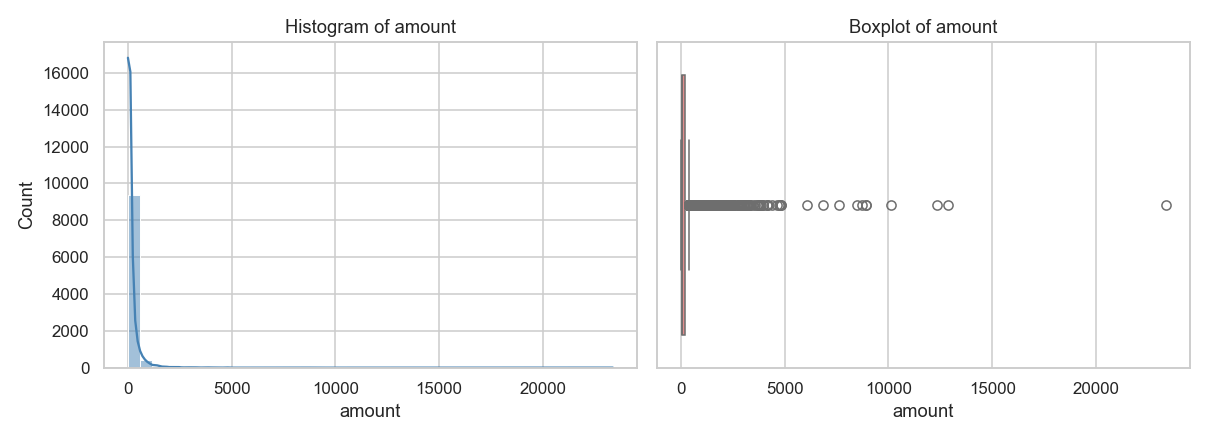

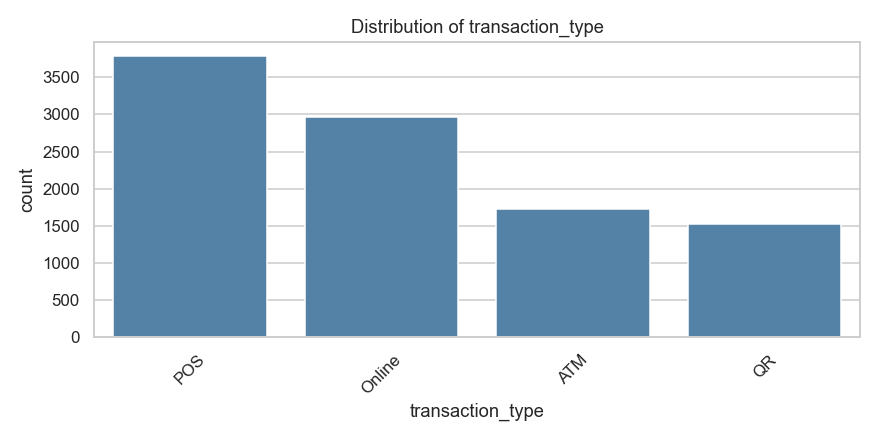

In [22]:
# Inline preview of a couple of key univariate charts
from IPython.display import Image, display
for name in ['target_is_fraud.png', 'num_amount.png', 'cat_transaction_type.png']:
    p = FIG_UNI / name
    if p.exists():
        display(Image(filename=str(p)))

## 4. Multivariate plots

In [23]:
eda.multivariate(df)
print('Saved multivariate figures to:', FIG_MULTI)

2026-05-26 15:52:05 | INFO     | eda | Saved correlation heatmap
2026-05-26 15:52:06 | INFO     | eda | Top correlated numeric features with target: ['device_risk_score', 'ip_risk_score', 'amount', 'hour']
Saved multivariate figures to: C:\Users\U1\Documents\fraud-1\outputs\figures\multivariate


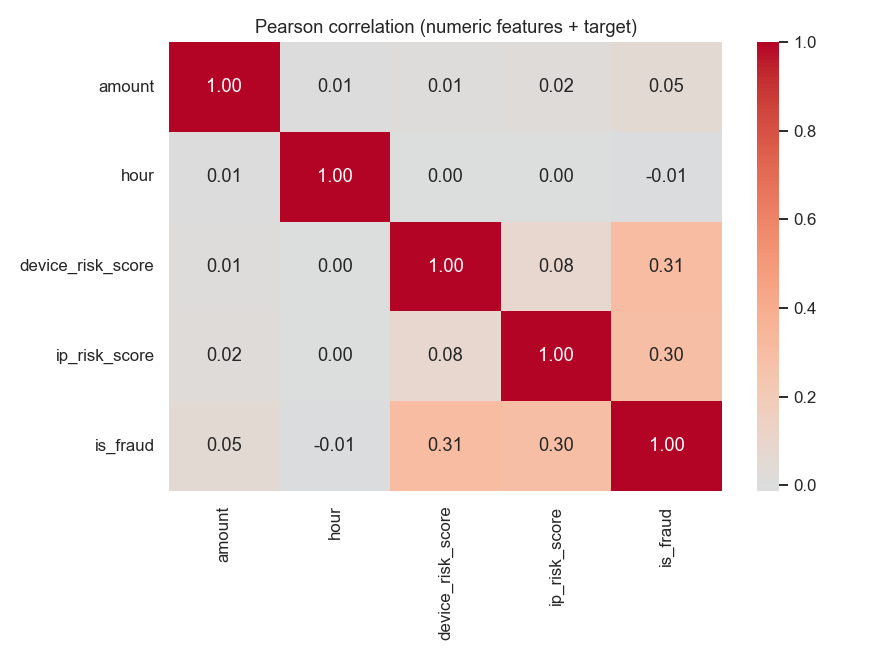

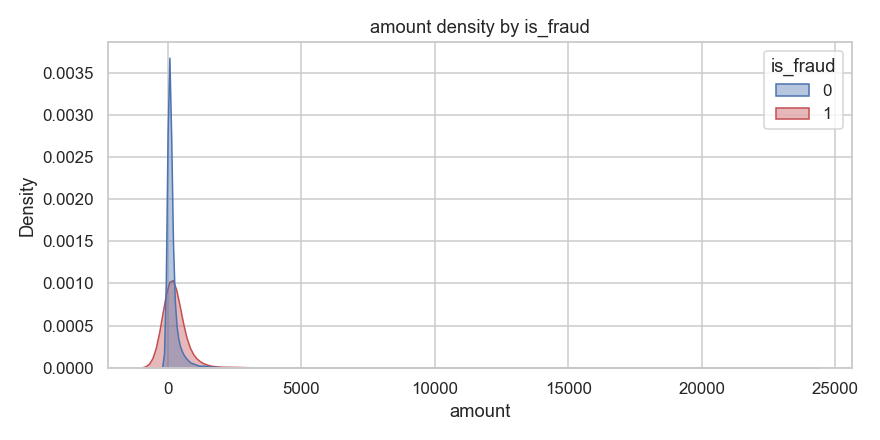

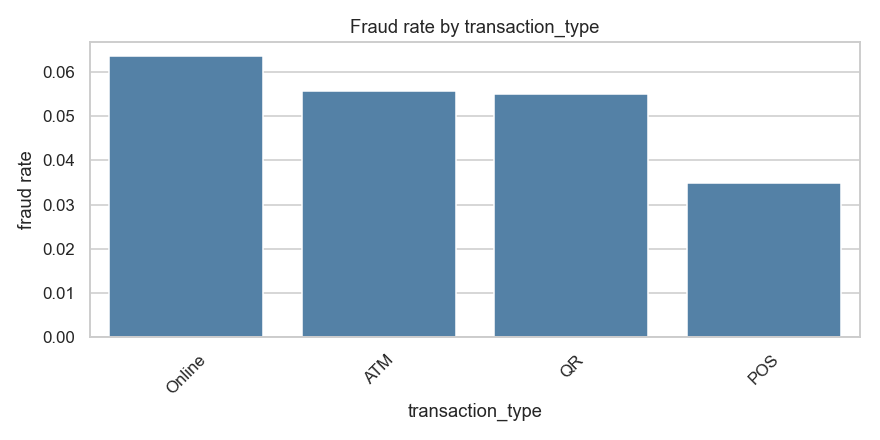

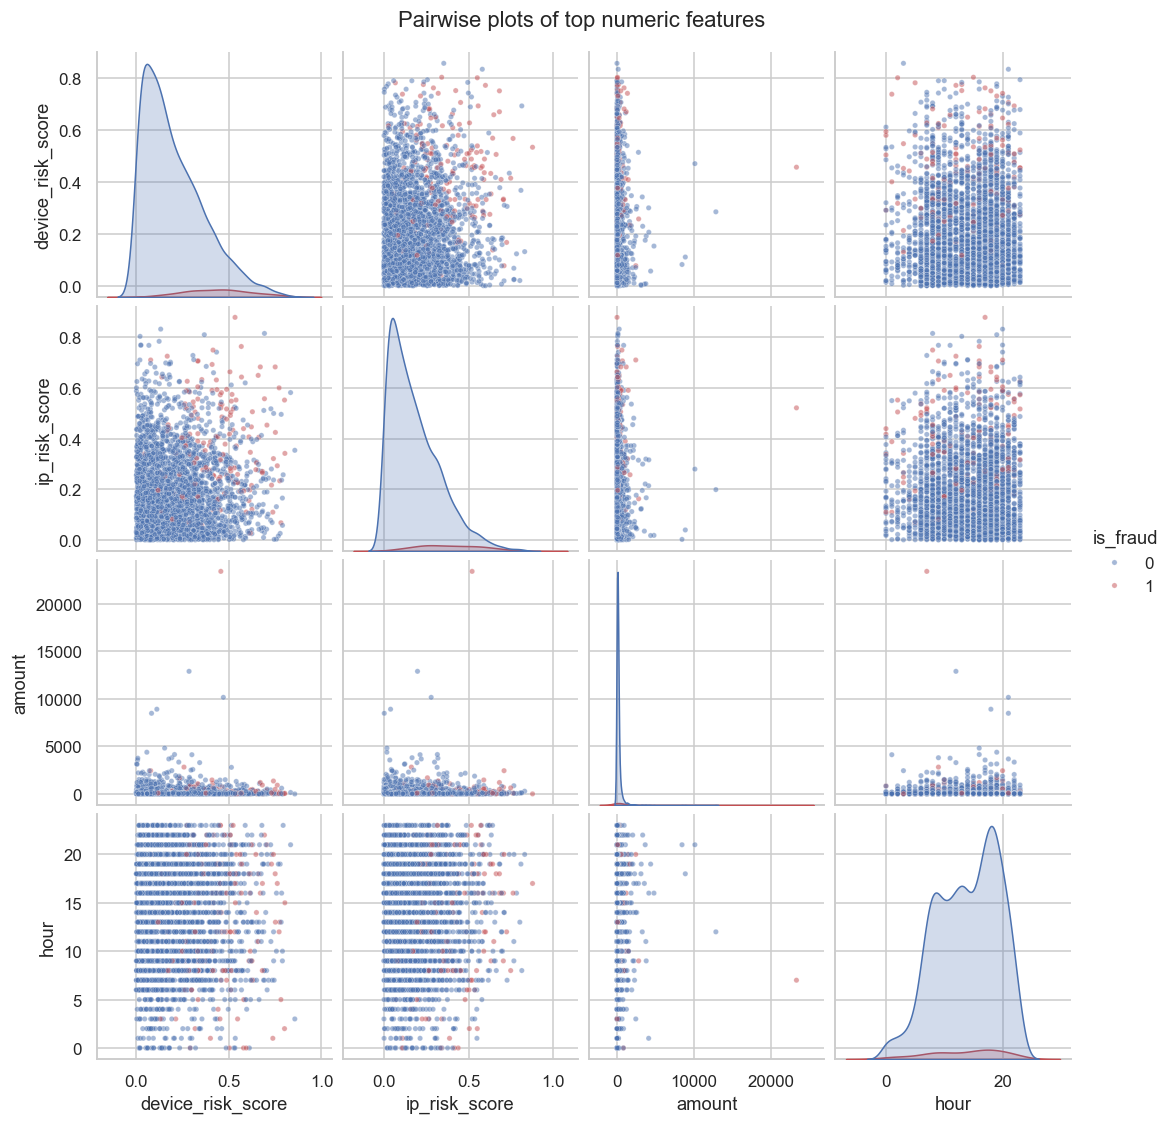

In [24]:
for name in ['correlation_heatmap.png', 'kde_amount_by_target.png', 'fraud_rate_by_transaction_type.png', 'pairplot_top_numeric.png']:
    p = FIG_MULTI / name
    if p.exists():
        display(Image(filename=str(p)))

## 5. Recap
- Class imbalance confirmed -> use **SMOTE** on train split only.
- Numeric vs categorical features identified -> drive the encoder in `preprocess.py`.
- Top-correlated numerics with target visualised above; FLAML will rank features automatically during the search.